1. sample from trained models and test pearson r with and without pre initializing nmf run 1
2. repeat this for each celltype combination to compute specificity (with rmsd against a diagonal matrix and using sinkhon_knopp from scipy)

In [1]:
import scvi
import scanpy as sc
from pathlib import Path
import numpy as np
import itertools
import pandas as pd
from sklearn.decomposition import non_negative_factorization
from tqdm import tqdm
from typing import Literal, Union
from anndata import AnnData
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def cosine_similarity_rows(A: np.array, B: np.array) -> np.array:
    norms_A = np.linalg.norm(A, axis=1)
    norms_B = np.linalg.norm(B, axis=1)
    dot_products = np.einsum('ij,ij->i', A, B)
    return dot_products / (norms_A * norms_B)

def non_negative_factorization_reimplementation(
        X: np.ndarray, 
        W: np.ndarray | None = None, 
        H: None | np.ndarray=None, 
        n_components: Union[None, int]=None, 
        init: Literal["custom"] | None=None,
        update_H: bool=True,
        max_iter: int=200
) -> tuple[np.ndarray, np.ndarray, int]:
    if n_components is None:
        if H is not None:
            n_components = H.shape[0]
        else:
            n_components = min(X.shape)
    if W is None and init != "custom":
        W = np.ones((X.shape[0], n_components))
    if H is None and init != "custom":
        H = np.ones((n_components, X.shape[1]))
    
    for _ in tqdm(range(max_iter)):
        W = (W.T * (H @ X.T) / (H @ H.T @ W.T + 1e-9)).T
        if update_H:
            H = (H * (W.T @ X) / (W.T @ W @ H + 1e-9))
    return W, H, max_iter

def sample_normalized_expression(
    adata: sc.AnnData,
    model: scvi.model._scvi.SCVI
) -> sc.AnnData:
    """
    Returns an AnnData object with counts sampled using a pretrained SCVI Model
    """
    return sc.AnnData(
        X=model.get_normalized_expression().values, 
        obs=adata.obs,
        var=adata.var,
    )

def paired_iterator_sampled_expression(
    n: int,
    a: tuple[sc.AnnData, scvi.model._scvi.SCVI],
    b: tuple[sc.AnnData, scvi.model._scvi.SCVI],
) -> zip:
    return (lambda f, n: lambda a, b: zip(
        [f(*a) for _ in range(n)], 
        [f(*b) for _ in range(n)]))(
        f=sample_normalized_expression,
        n=2
    )(a, b)

def nmf_transfer(
        adata_query: AnnData, 
        adata_reference: AnnData, 
        shared_genes_mask_reference: np.ndarray, 
        gene_filter_mask: np.ndarray | None = None,
        n_components: int | None = None, 
        nmf_func: callable = non_negative_factorization,
        W_init_reference: np.ndarray | None = None,
        H_init_reference: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

    shared_genes = adata_reference[:, shared_genes_mask_reference].var_names

    if gene_filter_mask is None:
        gene_filter_mask = np.ones(len(shared_genes), dtype=bool)

    init_reference = "custom" if W_init_reference is not None or H_init_reference is not None else None

    if W_init_reference is not None:
        W_init_reference = W_init_reference.copy(order="C")

    W, H, _, W_init, H_init = (
        lambda W_init, H_init, _: (
            *nmf_func(
                adata_query[:, shared_genes][:, gene_filter_mask].X.toarray(), 
                H=H_init[:, gene_filter_mask], 
                init="custom", 
                update_H=False
            ), 
            W_init, 
            H_init)
        )(
            *nmf_func(
                adata_reference[:, shared_genes_mask_reference].X.toarray(), 
                init=init_reference, 
                W=W_init_reference, 
                H=H_init_reference, 
                n_components=n_components
            )
        )
    return W, H, W_init, H_init

def benchmark_reconstruction(count_matrix: np.array, count_matrix_reconstructed: np.array) -> None:
    log_original = np.log1p(count_matrix)
    log_reconstructed = np.log1p(count_matrix_reconstructed)

    row_means_original = count_matrix.mean(axis=1)
    row_means_reconstructed = count_matrix_reconstructed.mean(axis=1)
    col_means_original = count_matrix.mean(axis=0)
    col_means_reconstructed = count_matrix_reconstructed.mean(axis=0)

    fig, axes = plt.subplots(3, 2, figsize=(6, 8))

    sns.heatmap(log_original, ax=axes[0, 0], cmap="magma", cbar=True)
    axes[0, 0].set_title("Log Transformed \n Original Count Matrix")

    sns.heatmap(log_reconstructed, ax=axes[0, 1], cmap="magma", cbar=True)
    axes[0, 1].set_title("Log Transformed \n Reconstructed Count Matrix")

    pearson_row, _ = pearsonr(row_means_original, row_means_reconstructed)
    axes[1, 0].scatter(row_means_original, row_means_reconstructed, alpha=0.5, color="black")
    axes[1, 0].plot([row_means_original.min(), row_means_original.max()], 
                    [row_means_original.min(), row_means_original.max()], 
                    linestyle="dashed", color="red")
    axes[1, 0].set_xlabel("Cell Mean (Original)")
    axes[1, 0].set_ylabel("Cell Mean (Reconstructed)")
    axes[1, 0].set_title("Cell-wise Mean Comparison")
    axes[1, 0].text(0.05, 0.9, f"Pearson r = {pearson_row:.2f}", 
                    transform=axes[1, 0].transAxes, fontsize=10, color="blue")
    
    pearson_col, _ = pearsonr(col_means_original, col_means_reconstructed)
    axes[1, 1].scatter(col_means_original, col_means_reconstructed, alpha=0.5, color="black")
    axes[1, 1].plot([col_means_original.min(), col_means_original.max()], 
                    [col_means_original.min(), col_means_original.max()], 
                    linestyle="dashed", color="red")
    axes[1, 1].set_xlabel("Gene Mean (Original)")
    axes[1, 1].set_ylabel("Gene Mean (Reconstructed)")
    axes[1, 1].set_title("Gene-wise Mean Comparison")
    axes[1, 1].text(0.05, 0.9, f"Pearson r = {pearson_col:.2f}", 
                    transform=axes[1, 1].transAxes, fontsize=10, color="blue")

    sns.violinplot(cosine_similarity_rows(count_matrix, count_matrix_reconstructed), ax=axes[2, 0])
    axes[2, 0].set_title("Cosine Similarity Cells")
    sns.violinplot(cosine_similarity_rows(count_matrix.T, count_matrix_reconstructed.T), ax=axes[2, 1])
    axes[2, 1].set_title("Cosine Similarity Genes")

    sns.despine()
    plt.tight_layout()
    plt.show()

In [3]:
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)
shared_genes_mask_sc = np.isin(adata_sc.var_names, adata_sp.var_names)
shared_genes_mask_sp = np.isin(adata_sp.var_names, adata_sc.var_names)
shared_genes = adata_sc[:, shared_genes_mask_sc].var_names
print(f"{len(shared_genes)=}")

len(shared_genes)=203


In [4]:
adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [15]:
test = (lambda f : lambda a, b: itertools.product(f(a), f(b)))(
    lambda adata: [adata[adata.obs["celltype"] == celltype] for celltype in set(adata.obs["celltype"])],
)(
    adata_sc,
    adata_sp
)

In [5]:
scvi.model.SCVI.setup_anndata(adata_sc)
model_sc = scvi.model.SCVI(adata_sc)
model_sc.train()

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator=='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of t

Epoch 400/400: 100%|██████████| 400/400 [40:27<00:00,  6.85s/it, v_num=1, train_loss_step=9.31e+3, train_loss_epoch=8.95e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [40:27<00:00,  6.07s/it, v_num=1, train_loss_step=9.31e+3, train_loss_epoch=8.95e+3]


In [8]:
scvi.model.SCVI.setup_anndata(adata_sp)
model_sp = scvi.model.SCVI(adata_sp)
model_sp.train(accelerator="mps")

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usuall. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [07:08<00:00,  1.38it/s, v_num=1, train_loss_step=73.3, train_loss_epoch=72.6]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [07:08<00:00,  1.07s/it, v_num=1, train_loss_step=73.3, train_loss_epoch=72.6]


In [19]:
adata_sp

AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype', '_scvi_batch', '_scvi_labels'
    var: 'n_counts'
    uns: '_scvi_uuid', '_scvi_manager_uuid'

In [20]:
set(adata_sp.obs["celltype"])

{'BZE',
 'Blood vasc.',
 'Cycling/GC B cell',
 'Glial',
 'Goblet',
 'Lymphatic',
 'MZE',
 'Macrophage',
 'NM',
 'Paneth',
 'Plasma',
 'Rest B',
 'Stem/TA',
 'Stroma',
 'T cell',
 'TZE',
 'Tuft',
 'cDC/monocyte',
 'neurons/enteroendocrine',
 'pDC'}

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


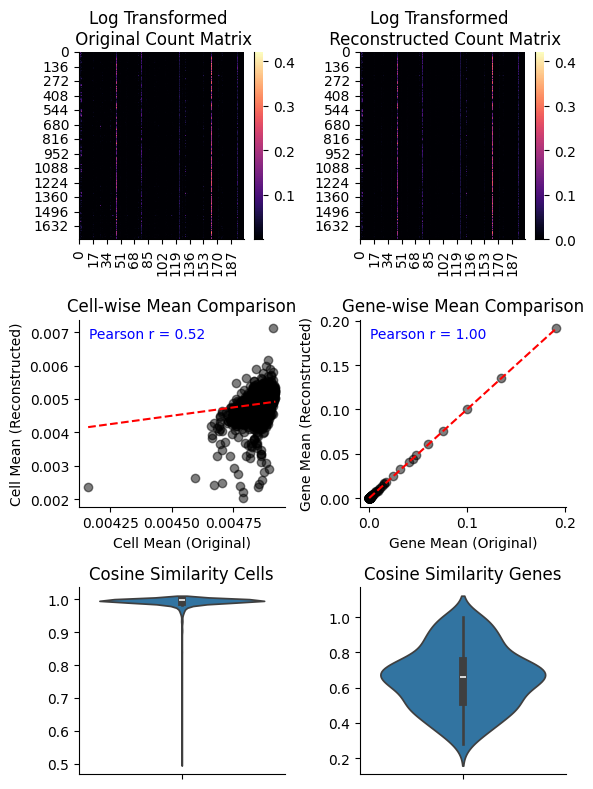

In [21]:
celltype = "BZE"
test_data_sp = (lambda ad: ad[ad.obs["celltype"] == celltype])(sample_normalized_expression(adata_sp, model_sp))
W, H, _ = non_negative_factorization(
    test_data_sp[:, shared_genes].X.toarray(),
    n_components=8
) 
benchmark_reconstruction(
    test_data_sp[:, shared_genes].X,
    W @ H
)

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


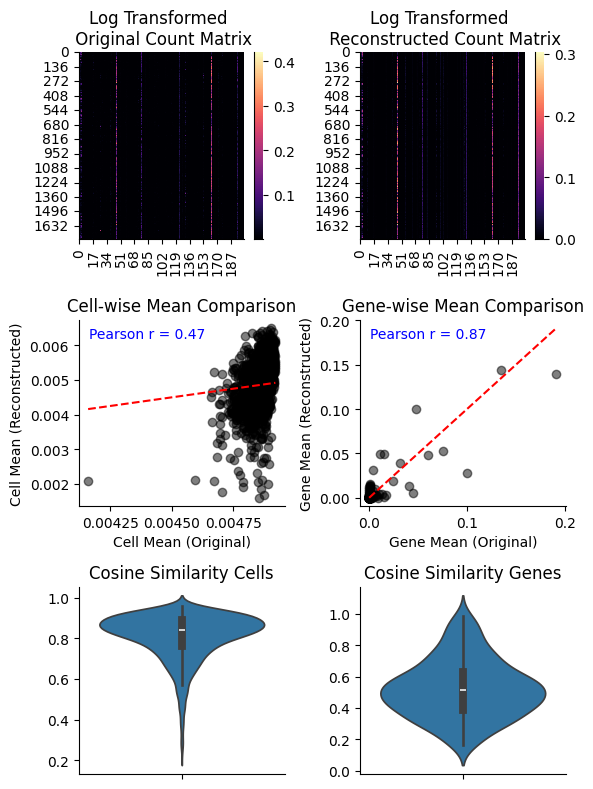

In [22]:
test_data_sc = (lambda ad: ad[ad.obs["celltype"] == celltype])(sample_normalized_expression(adata_sc, model_sc))
W, H, W_init, H_init = nmf_transfer(
    adata_query=test_data_sp,
    adata_reference=test_data_sc,
    shared_genes_mask_reference=shared_genes_mask_sc,
    n_components=8
)
benchmark_reconstruction(
    test_data_sp[:, shared_genes].X,
    W @ H
)

In [196]:
test_data_sp = sample_normalized_expression(adata_sp, model_sp)
W, H, _ = non_negative_factorization(
    adata_sp[:, shared_genes].X.toarray(), 
    n_components=8
) 

In [168]:
adata_sp[:, shared_genes].X.shape

(7416, 203)

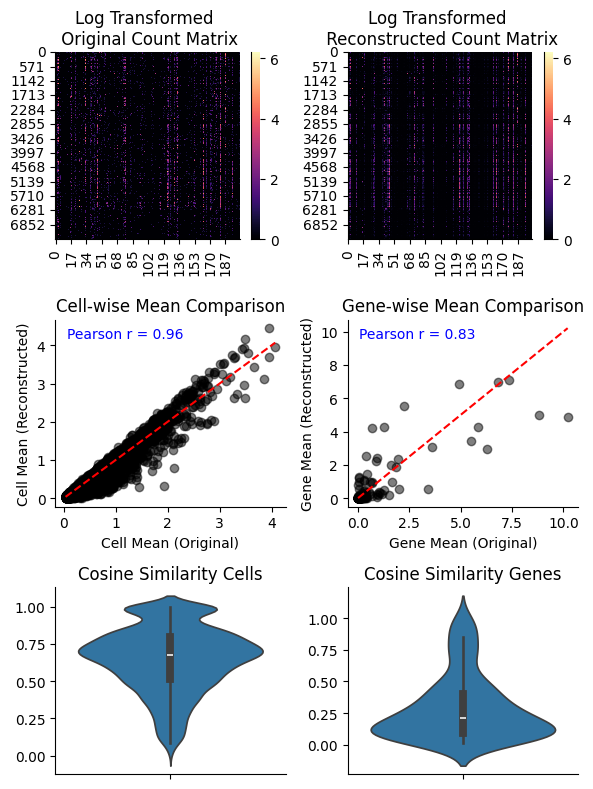

In [199]:
benchmark_reconstruction(
    adata_sp[:, shared_genes].X,
    W @ H
)

In [165]:
(W @ H).shape

(7416, 203)

In [ ]:
(lambda ad_sc, model_sc, ad_sp, model_sp: 
 itertools.zip(
     []
 ))

In [88]:
zip(
    [n for n in range(5)],
    [n for n in range(5)],
)

In [201]:
test = paired_iterator_sampled_expression(
    1,
    a=(adata_sc, model_sc),
    b=(adata_sp, model_sp)
)

In [202]:
for a, b in test:
    W, H, W_init, H_init = nmf_transfer(
        adata_query=b,
        adata_reference=a,
        shared_genes_mask_reference=shared_genes_mask_sc,
        n_components=8
    )

In [205]:
benchmark_reconstruction(b, (W @ H))

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x107e44970>>
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [204]:
b

AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype', '_scvi_batch', '_scvi_labels'
    var: 'n_counts'

In [203]:
W

array([[0.0000000e+00, 3.6701806e-02, 0.0000000e+00, ..., 0.0000000e+00,
        4.5986933e-01, 0.0000000e+00],
       [0.0000000e+00, 2.0558914e-02, 4.3802173e-04, ..., 0.0000000e+00,
        2.1929303e-01, 0.0000000e+00],
       [0.0000000e+00, 2.6639333e-02, 2.0951419e-03, ..., 0.0000000e+00,
        2.5173515e-01, 0.0000000e+00],
       ...,
       [1.1238707e-03, 3.8287543e-02, 0.0000000e+00, ..., 2.8296677e-02,
        3.2948276e-01, 0.0000000e+00],
       [0.0000000e+00, 3.3432856e-02, 0.0000000e+00, ..., 0.0000000e+00,
        9.0690809e-01, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 2.2399493e-03, ..., 1.7756282e-03,
        3.2435358e-02, 0.0000000e+00]], dtype=float32)